In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [160]:
df=pd.read_csv(r'D:\projectpart1\telco2\customer_ml_features.csv')

In [161]:
df.head()

,Unnamed: 0,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,...,payment_method,monthly_charges,total_charges,churn,tenure_bucket,high_charge_flag,service_count,is_long_term_customer,has_streaming_bundle,auto_pay_flag
0,0,7590-VHVEG,Female,0,1,0,1,0,No phone service,DSL,...,Electronic check,29.85,29.85,0,0-12,0,1,0,0,0
1,1,5575-GNVDE,Male,0,0,0,34,1,No,DSL,...,Mailed check,56.95,1889.50,0,25-48,0,2,1,0,0
2,2,3668-QPYBK,Male,0,0,0,2,1,No,DSL,...,Mailed check,53.85,108.15,1,0-12,0,2,0,0,0
3,3,7795-CFOCW,Male,0,0,0,45,0,No phone service,DSL,...,Bank transfer (automatic),42.30,1840.75,0,25-48,0,3,1,0,1
4,4,9237-HQITU,Female,0,0,0,2,1,No,Fiber optic,...,Electronic check,70.70,151.65,1,0-12,1,0,0,0,0


In [162]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 7043
Columns: 28


In [163]:
#Drop customer_id
df.drop('customer_id', axis=1,inplace=True)


In [164]:
df.head()

,Unnamed: 0,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,payment_method,monthly_charges,total_charges,churn,tenure_bucket,high_charge_flag,service_count,is_long_term_customer,has_streaming_bundle,auto_pay_flag
0,0,Female,0,1,0,1,0,No phone service,DSL,No,...,Electronic check,29.85,29.85,0,0-12,0,1,0,0,0
1,1,Male,0,0,0,34,1,No,DSL,Yes,...,Mailed check,56.95,1889.50,0,25-48,0,2,1,0,0
2,2,Male,0,0,0,2,1,No,DSL,Yes,...,Mailed check,53.85,108.15,1,0-12,0,2,0,0,0
3,3,Male,0,0,0,45,0,No phone service,DSL,Yes,...,Bank transfer (automatic),42.30,1840.75,0,25-48,0,3,1,0,1
4,4,Female,0,0,0,2,1,No,Fiber optic,No,...,Electronic check,70.70,151.65,1,0-12,1,0,0,0,0


In [165]:
target_col = "churn"

print("Target Column:")
print(target_col)

Target Column:
churn


In [166]:
numeric_cols = [
    "tenure",
    "monthly_charges",
    "total_charges",
    "service_count",
    "high_charge_flag",
    "is_long_term_customer",
    "auto_pay_flag",
    "has_streaming_bundle"
]

print("Numeric Columns:")

for col in numeric_cols:
    print("-", col)

Numeric Columns:
- tenure
- monthly_charges
- total_charges
- service_count
- high_charge_flag
- is_long_term_customer
- auto_pay_flag
- has_streaming_bundle


In [167]:
cat_cols = [
    "contract",
    "internet_service"]
print("Categorical Columns:")
for col in cat_cols:
    print("-", col)

Categorical Columns:
- contract
- internet_service


In [168]:
drop_col = "customer_id"
X = df.drop(columns=[target_col])

X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True
)

y = df[target_col]

print("Encoding complete.")

Encoding complete.


In [169]:
# 243. Print feature set and target

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 rows of X:")
display(X.head())

print("\nFirst 5 values of y:")
display(y.head())

X shape: (7043, 28)
y shape: (7043,)

First 5 rows of X:


,Unnamed: 0,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,online_security,online_backup,...,tenure_bucket,high_charge_flag,service_count,is_long_term_customer,has_streaming_bundle,auto_pay_flag,contract_One year,contract_Two year,internet_service_Fiber optic,internet_service_No
0,0,Female,0,1,0,1,0,No phone service,No,Yes,...,0-12,0,1,0,0,0,False,False,False,False
1,1,Male,0,0,0,34,1,No,Yes,No,...,25-48,0,2,1,0,0,True,False,False,False
2,2,Male,0,0,0,2,1,No,Yes,Yes,...,0-12,0,2,0,0,0,False,False,False,False
3,3,Male,0,0,0,45,0,No phone service,Yes,No,...,25-48,0,3,1,0,1,True,False,False,False
4,4,Female,0,0,0,2,1,No,No,No,...,0-12,1,0,0,0,0,False,False,True,False



First 5 values of y:


0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64

In [170]:

class_balance = y.value_counts(normalize=True)
print("Class Balance:")
print(class_balance)

print("\nPercentage:")
print((class_balance * 100).round(2))

Class Balance:
churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64

Percentage:
churn
0    73.46
1    26.54
Name: proportion, dtype: float64


In [171]:
# 245. Discussion

print("""
Class Imbalance Discussion

• The dataset is approximately 73% non-churn (0) and 27% churn (1).
• This means the classes are imbalanced.

Why is this a problem?
• A model could predict every customer as non-churn (0)
  and still achieve about 73% accuracy.

Therefore:
• Accuracy should NOT be the primary evaluation metric.

Better metrics:
• Precision
• Recall
• F1-score
• ROC-AUC
• PR-AUC (Precision-Recall AUC)

For model training:
• Use stratified train-test splits.
• Consider class_weight='balanced' for some algorithms.
""")



Class Imbalance Discussion

• The dataset is approximately 73% non-churn (0) and 27% churn (1).
• This means the classes are imbalanced.

Why is this a problem?
• A model could predict every customer as non-churn (0)
  and still achieve about 73% accuracy.

Therefore:
• Accuracy should NOT be the primary evaluation metric.

Better metrics:
• Precision
• Recall
• F1-score
• ROC-AUC
• PR-AUC (Precision-Recall AUC)

For model training:
• Use stratified train-test splits.
• Consider class_weight='balanced' for some algorithms.



In [172]:
# ML2

In [173]:

y = df["churn"]

# Automatically encode every categorical column
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(X.head())

(7043, 39)
   Unnamed: 0  senior_citizen  partner  dependents  tenure  phone_service  \
0           0               0        1           0       1              0   
1           1               0        0           0      34              1   
2           2               0        0           0       2              1   
3           3               0        0           0      45              0   
4           4               0        0           0       2              1   

   paperless_billing  monthly_charges  total_charges  high_charge_flag  ...  \
0                  1            29.85          29.85                 0  ...   
1                  0            56.95        1889.50                 0  ...   
2                  1            53.85         108.15                 0  ...   
3                  0            42.30        1840.75                 0  ...   
4                  1            70.70         151.65                 1  ...   

   streaming_tv_No internet service  streaming_tv_Y

In [174]:
print(df.columns.tolist())

['Unnamed: 0', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn', 'tenure_bucket', 'high_charge_flag', 'service_count', 'is_long_term_customer', 'has_streaming_bundle', 'auto_pay_flag']


In [175]:
X_api=df[[
    "tenure",
    "monthly_charges",
    "service_count",
    "contract"
]]

X_api = pd.get_dummies(
    X_api,
    columns=["contract"],
    drop_first=True
)

y = df["churn"]

In [176]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5634, 39)
X_test : (1409, 39)
y_train: (5634,)
y_test : (1409,)


In [177]:
print(X_train.select_dtypes(include="object").columns.tolist())

[]


In [178]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [179]:
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)


In [180]:
from sklearn.tree import DecisionTreeClassifier

dtree_api = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dtree_api.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [181]:
# 247. Train models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

log_reg = LogisticRegression(max_iter=1000)

dtree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

log_reg.fit(X_train, y_train)
dtree.fit(X_train, y_train)

print("Models trained successfully.")

Models trained successfully.


c:\Users\aravind.harish\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [182]:
# 248. Predict on test set

y_pred_lr = log_reg.predict(X_test)
y_pred_dt = dtree_api.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [183]:
# 249 & 250. Logistic Regression metrics

from sklearn.metrics import classification_report, confusion_matrix

print("=== Logistic Regression ===\n")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Active", "Churned"]
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

=== Logistic Regression ===

              precision    recall  f1-score   support

      Active       0.84      0.90      0.87      1035
     Churned       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409

Confusion Matrix:
[[929 106]
 [183 191]]


In [184]:
from sklearn.metrics import classification_report

y_pred = dtree_api.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [185]:
# 249 & 250. Decision Tree metrics

print("=== Decision Tree (max_depth=5) ===\n")

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=["Active", "Churned"]
    )
)



=== Decision Tree (max_depth=5) ===

              precision    recall  f1-score   support

      Active       0.84      0.89      0.86      1035
     Churned       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [186]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Confusion Matrix:
[[916 119]
 [172 202]]


In [187]:
# 251. Cross-validation F1

from sklearn.model_selection import cross_val_score

cv_f1_lr = cross_val_score(
    log_reg,
    X,
    y,
    cv=5,
    scoring="f1"
)

cv_f1_dt = cross_val_score(
    dtree,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("Logistic Regression CV F1 Scores:")
print(cv_f1_lr)
print("Mean CV F1:", cv_f1_lr.mean())

print("\nDecision Tree CV F1 Scores:")
print(cv_f1_dt)
print("Mean CV F1:", cv_f1_dt.mean())


c:\Users\aravind.harish\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\aravind.harish\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown

Logistic Regression CV F1 Scores:
[0.58192956 0.57957958 0.5659824  0.61918605 0.5982659 ]
Mean CV F1: 0.5889886965265824

Decision Tree CV F1 Scores:
[0.50079239 0.47260274 0.47790507 0.52072968 0.44254279]
Mean CV F1: 0.4829145357195152


c:\Users\aravind.harish\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [188]:
# 252. Comparison table

from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision (Churned)": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt)
    ],
    "Recall (Churned)": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt)
    ],
    "F1 (Churned)": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt)
    ],
    "CV F1": [
        cv_f1_lr.mean(),
        cv_f1_dt.mean()
    ]
})

results = results.round(4)

results

,Model,Accuracy,Precision (Churned),Recall (Churned),F1 (Churned),CV F1
0,Logistic Regression,0.7949,0.6431,0.5107,0.5693,0.5890
1,Decision Tree,0.7935,0.6293,0.5401,0.5813,0.4829


In [189]:
results.sort_values(
    by="F1 (Churned)",
    ascending=False
)

,Model,Accuracy,Precision (Churned),Recall (Churned),F1 (Churned),CV F1
1,Decision Tree,0.7935,0.6293,0.5401,0.5813,0.4829
0,Logistic Regression,0.7949,0.6431,0.5107,0.5693,0.5890


In [190]:
import os
import joblib

# Create models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Save models
joblib.dump(log_reg, "models/logistic_churn.pkl")
joblib.dump(dtree, "models/tree_churn.pkl")

print("Models saved successfully.")

Models saved successfully.


In [191]:
import os

print(os.listdir("models"))


['feature_columns.pkl', 'logistic_churn.pkl', 'tree_churn.pkl']


In [192]:
#ML3

In [193]:
import joblib

best_model = joblib.load("models/tree_churn.pkl")
print(type(best_model))

<class 'sklearn.tree._classes.DecisionTreeClassifier'>


Top features:
tenure                                 0.421181
internet_service_Fiber optic           0.357327
payment_method_Electronic check        0.036320
total_charges                          0.035387
monthly_charges                        0.027500
multiple_lines_Yes                     0.023616
online_security_No internet service    0.020656
contract_Two year                      0.019587
internet_service_No                    0.017368
tech_support_Yes                       0.012980
dtype: float64


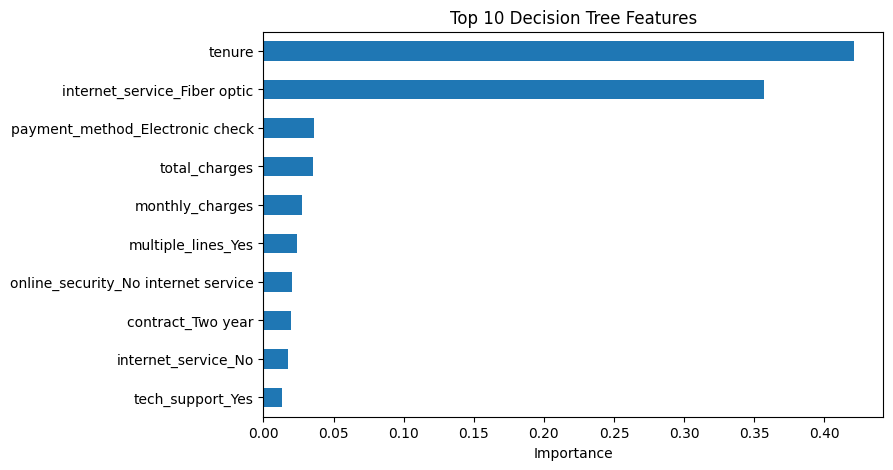

In [194]:
import pandas as pd
import matplotlib.pyplot as plt

importance_series = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importance_series = importance_series.sort_values(
    ascending=False
)

print("Top features:")
print(importance_series.head(10))

plt.figure(figsize=(8,5))
importance_series.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Decision Tree Features")
plt.xlabel("Importance")
plt.show()

In [195]:
top3_features = importance_series.head(3)

print("Top 3 important features:")
print(top3_features)


Top 3 important features:
tenure                             0.421181
internet_service_Fiber optic       0.357327
payment_method_Electronic check    0.036320
dtype: float64


In [196]:
risk_scores = best_model.predict_proba(X_test)[:, 1]

risk_scores[:10]

array([0.        , 0.75087719, 0.1027668 , 0.33793103, 0.        ,
       0.3220339 , 0.3220339 , 0.03010033, 0.02988506, 0.03010033])

In [197]:
df_original = pd.read_csv(r"D:\projectpart1\telco2\customer_features.csv")
customer_ids = df_original["customer_id"]

#X = df.drop(columns=["customer_id", "churn"])
X = pd.get_dummies(X, drop_first=True)

y = df["churn"]



In [198]:

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X,
    y,
    customer_ids,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [199]:
# Get churn probabilities
# Create risk dataframe

risk_df = pd.DataFrame({
    "customer_id": ids_test.values,
    "risk_score": risk_scores
})

# Top 20 highest-risk customers

top20 = risk_df.sort_values(
    by="risk_score",
    ascending=False
).head(20)

print("Top 20 Highest-Risk Customers")
display(top20)


Top 20 Highest-Risk Customers


,customer_id,risk_score
580,4742-TXUEX,1.000000
1393,0679-IDSTG,0.888268
51,7181-BQYBV,0.888268
69,8821-XNHVZ,0.888268
740,3716-BDVDB,0.888268
648,9940-RHLFB,0.888268
1259,2609-IAICY,0.888268
749,7409-KIUTL,0.888268
278,3722-WPXTK,0.888268
762,2202-CUYXZ,0.888268


Customers most likely to churn are 20 highest-risk customers

Optional:

/list from SQL6:

particularly customers with [Feature 1], [Feature 2], and [Feature 3]. These factors were the strongest predictors of churn across the customer base. Customers displaying these patterns should be prioritized for proactive retention campaigns and personalized offers. The top-risk customers identified by the model represent the group most likely to leave if no action is taken. By targeting these customers early, the retention team can reduce customer loss and improve long-term revenue.

In [200]:
print(X.columns.tolist())

['Unnamed: 0', 'senior_citizen', 'partner', 'dependents', 'tenure', 'phone_service', 'paperless_billing', 'monthly_charges', 'total_charges', 'high_charge_flag', 'service_count', 'is_long_term_customer', 'has_streaming_bundle', 'auto_pay_flag', 'contract_One year', 'contract_Two year', 'internet_service_Fiber optic', 'internet_service_No', 'gender_Male', 'multiple_lines_No phone service', 'multiple_lines_Yes', 'online_security_No internet service', 'online_security_Yes', 'online_backup_No internet service', 'online_backup_Yes', 'device_protection_No internet service', 'device_protection_Yes', 'tech_support_No internet service', 'tech_support_Yes', 'streaming_tv_No internet service', 'streaming_tv_Yes', 'streaming_movies_No internet service', 'streaming_movies_Yes', 'payment_method_Credit card (automatic)', 'payment_method_Electronic check', 'payment_method_Mailed check', 'tenure_bucket_13-24', 'tenure_bucket_25-48', 'tenure_bucket_49-72']


In [201]:
print(model.feature_names_in_)

['senior_citizen' 'partner' 'dependents' 'tenure' 'phone_service'
 'online_security' 'online_backup' 'device_protection' 'tech_support'
 'streaming_tv' 'streaming_movies' 'paperless_billing' 'monthly_charges'
 'total_charges' 'high_charge_flag' 'service_count' 'has_streaming_bundle'
 'auto_pay_flag' 'is_long_term_customer' 'contract_One year'
 'contract_Two year' 'internet_service_Fiber optic' 'internet_service_No'
 'gender_Male' 'multiple_lines_No phone service' 'multiple_lines_Yes'
 'payment_method_Credit card (automatic)'
 'payment_method_Electronic check' 'payment_method_Mailed check'
 'tenure_bucket_13-24' 'tenure_bucket_25-48' 'tenure_bucket_49-72']
